# UCR 112

Default HashBoost against QUANT's own classifier (ExtraTrees) and XGBoost on
the 112 equal-length UCR datasets, each on the archive's default train/test
split. Every number here comes from the result files `scripts/ucr_benchmark.py`
wrote, one per dataset under `results/UCR/`; nothing in this notebook trains
anything.

All three models see the same QUANT features. Nothing is tuned or
early-stopped, because UCR has no validation split to choose on:

* **HashBoost**: the MONSTER default (8 bits, lr 0.1) for a fixed 800 rounds,
  in batches of at most 4,096 rows cycled until the budget is spent.
* **ExtraTrees**: QUANT's classifier (200 trees, entropy, `max_features` 0.1),
  on the CPU with 12 threads.
* **XGBoost**: library defaults (100 rounds, eta 0.3, depth 6), on the GPU.

The reported number is each finished model's test error. Every cell is **one
run**. The bake-off averages 30 resamples; this is the default split only.

In [1]:
import json
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.transforms import Bbox
from scipy import stats

RESULTS = Path("../results/UCR")
FIGURES = Path("../paper/figures")

# Every dataset was run at this commit, so they share code and settings.
COMMIT = "84ac59c"

MODELS = ["hashboost", "extratrees", "xgboost"]
NAMES = {
    "hashboost": "HashBoost",
    "extratrees": "ExtraTrees",
    "xgboost": "XGBoost",
    "QUANT": "QUANT (published)",
    "HC2": "HC2 (published)",
}

# the subgroup nearest HashBoost's design point: at least this many training rows
LARGE = 1000

# published default-split (resample 0) accuracies, from the bake-off's results
PUBLISHED = ["QUANT", "HC2"]
PUBLISHED_URL = (
    "https://timeseriesclassification.com/results/ReferenceResults/"
    "classification/accuracy/{}_accuracy.csv"
)

paths = sorted(RESULTS.glob(f"*-{COMMIT}.json"))
len(paths)

112

## Style

The palette and chrome of the other notebooks. There is one hue per model, the
same in every figure: blue is HashBoost, orange ExtraTrees and aqua XGBoost.
These are the palette's first three slots, which stay distinguishable in
every pair under colour-vision deficiency. Aqua sits below 3:1 against the
surface, so everything it colours is also named in a legend or a direct
label. Where only HashBoost matters, it is the one hue and the rest is grey.

In [2]:
SURFACE = "#fcfcfb"
INK = "#0b0b0b"
INK_2 = "#52514e"
MUTED = "#8a8880"
GRID = "#e6e5e1"

BLUE = "#2a78d6"
ORANGE = "#eb6834"
AQUA = "#1baf7a"

COLOURS = {"hashboost": BLUE, "extratrees": ORANGE, "xgboost": AQUA}

plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK_2,
        "axes.titlecolor": INK,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.labelsize": 9,
        "axes.grid": True,
        "axes.axisbelow": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "grid.linestyle": "-",
        "xtick.color": INK_2,
        "ytick.color": INK_2,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "legend.frameon": False,
        "legend.fontsize": 8.5,
        "lines.linewidth": 2.0,
        "lines.solid_capstyle": "round",
        "lines.solid_joinstyle": "round",
        "figure.dpi": 120,
        "pdf.fonttype": 42,
    }
)


def finish(ax, title=None, note=None, xlabel=None, ylabel=None):
    """Title, optional sub-note, recessive chrome."""

    if title:
        ax.set_title(title, pad=16 if note else 8)
    if note:
        ax.text(
            0.0,
            1.02,
            note,
            transform=ax.transAxes,
            fontsize=8.5,
            color=INK_2,
            va="bottom",
        )
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    return ax


def dot(ax, x, y, colour, size=6, **kwargs):
    """A marker with a surface ring, so overlapping points stay legible."""

    ax.plot(
        x,
        y,
        "o",
        color=colour,
        markersize=size,
        markeredgecolor=SURFACE,
        markeredgewidth=1.2,
        linestyle="none",
        zorder=4,
        **kwargs,
    )


def save(fig, name):
    """Export a figure for the paper, beside showing it here.

    Without a creation date the PDF is the same bytes on every run, so
    rerunning the notebook only changes the figures whose content changed.
    """

    FIGURES.mkdir(parents=True, exist_ok=True)
    fig.savefig(
        FIGURES / f"{name}.pdf", bbox_inches="tight", metadata={"CreationDate": None}
    )


NEAR = ((8, 4), (8, -12), (-8, 4), (-8, -12))
FAR = ((8, 16), (8, -24), (-8, 16), (-8, -24))


def place_labels(ax, items, points, offsets=NEAR + FAR):
    """Name a few points without covering any: each label takes the first free spot.

    `items` is (x, y, text) for the points to name, and `points` is (x, y) for
    every point drawn, all of which a label must keep clear of, as it must of
    the axis edges and the labels already placed. A label with no free spot is
    left off; the tables carry every value. Call it once the layout is final,
    because it works in pixels.
    """

    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    frame = ax.get_window_extent(renderer)

    def around(x, y, half=6):
        px, py = ax.transData.transform((x, y))
        return Bbox.from_extents(px - half, py - half, px + half, py + half)

    taken = [around(x, y) for x, y in points]

    for x, y, text in items:
        for dx, dy in offsets:
            label = ax.annotate(
                text,
                (x, y),
                textcoords="offset points",
                xytext=(dx, dy),
                ha="left" if dx > 0 else "right",
                fontsize=7.5,
                color=INK_2,
                zorder=5,
            )
            box = label.get_window_extent(renderer).expanded(1.04, 1.15)

            within = frame.contains(box.x0, box.y0) and frame.contains(box.x1, box.y1)

            if within and not any(box.overlaps(other) for other in taken):
                taken.append(box)
                break

            label.remove()

## Loading

`runs` has one row per (dataset, model). `error` and `fit_s` pivot it to one
row per dataset. `curves` holds HashBoost's test error every 50 rounds, which
was recorded for plotting only. The run chose nothing on it.

In [3]:
def load(paths):
    """-> (one row per dataset and model, HashBoost's test curve per dataset)."""

    rows, curves = [], {}

    for path in paths:
        blob = json.loads(path.read_text())
        split = blob["split"]

        for model, entry in blob["models"].items():
            fit = next(t for t in entry["timings"] if t["phase"] == "fit")

            rows.append(
                {
                    "dataset": blob["dataset"],
                    "model": model,
                    "error": entry["final"]["te"],
                    "train_error": entry["final"]["tr"],
                    "fit_s": fit["wall_s"],
                    "n_tr": split["n_tr"],
                    "n_te": split["n_te"],
                    "length": split["length"],
                    "classes": split["num_classes"],
                    "features": blob["transform"]["num_features"],
                    "transform_s": blob["transform"]["transform_s"],
                }
            )

            if model == "hashboost":
                te = entry["results"]["te"]["merror"]
                curves[blob["dataset"]] = pd.Series(te["y"], index=te["x"])

    return pd.DataFrame(rows), pd.DataFrame(curves).T


runs, curves = load(paths)

error = runs.pivot(index="dataset", columns="model", values="error")[MODELS]
train_error = runs.pivot(index="dataset", columns="model", values="train_error")[MODELS]
fit_s = runs.pivot(index="dataset", columns="model", values="fit_s")[MODELS]

meta = runs.drop_duplicates("dataset").set_index("dataset")[
    ["n_tr", "n_te", "length", "classes", "features", "transform_s"]
]
large = meta.index[meta.n_tr >= LARGE]

missing = error.isna().sum()
assert len(error) == 112 and not missing.any(), missing

print(f"{len(error)} datasets, {len(large)} with at least {LARGE:,} training rows")

112 datasets, 11 with at least 1,000 training rows


## Published results

The default split is resample 0 in the bake-off's result files, so its QUANT
and HC2 accuracies are directly comparable. Published QUANT is ExtraTrees on
upstream QUANT, and our ExtraTrees column should reproduce it up to the
forest's randomness. That checks the loader and the torch QUANT port end to
end. HC2 is the bake-off's most accurate classifier, and it is here only as
context.

In [4]:
def published(name):
    """Default-split error per dataset, from a copy cached beside the results."""

    cache = RESULTS / "published" / f"{name}_accuracy.csv"

    if not cache.exists():
        cache.parent.mkdir(parents=True, exist_ok=True)
        urllib.request.urlretrieve(PUBLISHED_URL.format(name), cache)

    accuracy = pd.read_csv(cache, index_col=0)["0"]

    return 1 - accuracy


reference = pd.DataFrame({name: published(name) for name in PUBLISHED})
reference = reference.reindex(error.index)

assert not reference.isna().any().any(), reference.isna().sum()

gap = error["extratrees"] - reference["QUANT"]

pd.Series(
    {
        "mean error, our ExtraTrees": error["extratrees"].mean(),
        "mean error, published QUANT": reference["QUANT"].mean(),
        "mean difference": gap.mean(),
        "mean absolute difference": gap.abs().mean(),
        "correlation": error["extratrees"].corr(reference["QUANT"]),
        "datasets within 0.02": (gap.abs() <= 0.02).sum(),
    }
).round(4)

mean error, our ExtraTrees       0.1475
mean error, published QUANT      0.1456
mean difference                  0.0019
mean absolute difference         0.0072
correlation                      0.9962
datasets within 0.02           100.0000
dtype: float64

In [5]:
# the largest disagreements, with the test-set size that bounds their noise
(
    pd.DataFrame(
        {
            "ours": error["extratrees"],
            "published": reference["QUANT"],
            "difference": gap,
            "n_tr": meta.n_tr,
            "n_te": meta.n_te,
        }
    )
    .reindex(gap.abs().sort_values(ascending=False).index)
    .head(8)
    .round(4)
)

,ours,published,difference,n_tr,n_te
dataset,,,,,
Ham,0.2952,0.2476,0.0476,109,105
Lightning7,0.2603,0.2192,0.0411,70,73
EOGHorizontalSignal,0.3425,0.3039,0.0387,362,362
DistalPhalanxOutlineAgeGroup,0.2230,0.2590,-0.0360,400,139
Computers,0.2240,0.1920,0.0320,250,250
Herring,0.3594,0.3906,-0.0312,64,64
SmallKitchenAppliances,0.1520,0.1813,-0.0293,375,375
SonyAIBORobotSurface2,0.1459,0.1175,0.0283,27,953


## Summary

Mean error is taken over datasets. Mean rank is among our three models (1 is
the lowest error, ties share the average rank). W/T/L is HashBoost's record
against each column: datasets where HashBoost's error is lower, equal, or
higher. The p-values are two-sided Wilcoxon signed-rank tests of HashBoost
against each column, Holm-adjusted over the four comparisons.

In [6]:
def holm(pvalues):
    """Holm-Bonferroni adjusted p-values, in the order given."""

    pvalues = np.asarray(pvalues, dtype=float)
    adjusted = np.empty_like(pvalues)
    running = 0.0

    for step, i in enumerate(np.argsort(pvalues)):
        running = max(running, (len(pvalues) - step) * pvalues[i])
        adjusted[i] = min(1.0, running)

    return adjusted


def summarise(errors, times):
    """One row per model: its errors, its rank, and HashBoost's record against it."""

    ranks = errors[MODELS].rank(axis=1, method="average").mean()
    others = [c for c in errors.columns if c != "hashboost"]

    p = holm([stats.wilcoxon(errors["hashboost"], errors[c]).pvalue for c in others])
    p = dict(zip(others, p))

    rows = {}

    for column in errors.columns:
        difference = errors["hashboost"] - errors[column]

        rows[NAMES[column]] = {
            "mean error": f"{errors[column].mean():.4f}",
            "median error": f"{errors[column].median():.4f}",
            "mean rank": f"{ranks[column]:.2f}" if column in ranks else "--",
            "HashBoost W/T/L": (
                "--"
                if column == "hashboost"
                else f"{(difference < 0).sum()}/{(difference == 0).sum()}"
                f"/{(difference > 0).sum()}"
            ),
            "p (Holm)": f"{p[column]:.2g}" if column in p else "--",
            "total fit s": f"{times[column].sum():.0f}" if column in times else "--",
        }

    return pd.DataFrame(rows).T


everything = pd.concat([error, reference], axis=1)

summary = summarise(everything, fit_s)
summary_large = summarise(everything.loc[large], fit_s.loc[large])

summary

,mean error,median error,mean rank,HashBoost W/T/L,p (Holm),total fit s
HashBoost,0.1941,0.1705,2.36,--,--,183
ExtraTrees,0.1475,0.1205,1.25,8/8/96,2.6e-14,70
XGBoost,0.2101,0.1912,2.39,58/3/51,0.082,413
QUANT (published),0.1456,0.1177,--,13/5/94,4.9e-14,--
HC2 (published),0.1236,0.0753,--,8/7/97,3.8e-15,--


In [7]:
summary_large

,mean error,median error,mean rank,HashBoost W/T/L,p (Holm),total fit s
HashBoost,0.1225,0.0919,2.64,--,--,24
ExtraTrees,0.0973,0.0672,1.36,1/0/10,0.012,37
XGBoost,0.1054,0.0758,2.00,3/0/8,0.032,101
QUANT (published),0.0973,0.0682,--,2/0/9,0.015,--
HC2 (published),0.0916,0.0504,--,1/0/10,0.02,--


## Critical difference

This is the Friedman test over our three models, followed by the Nemenyi
post-hoc test, as Demšar (2006) recommends. Two models whose average ranks
differ by less than the critical difference are not significantly different
at the 0.05 level, and the diagram joins them with a bar.

Friedman p = 3.6e-22, Nemenyi CD = 0.313 over 112 datasets


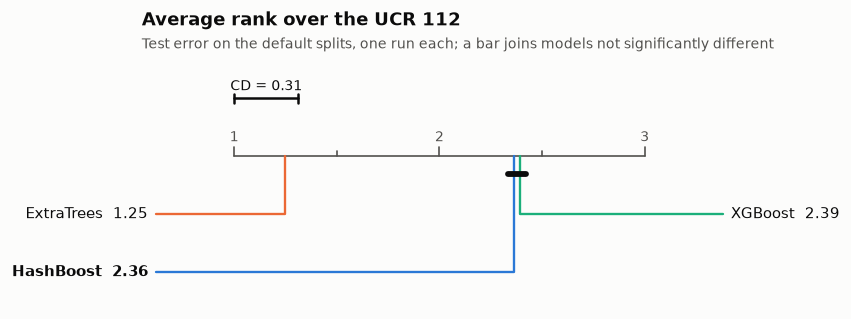

In [8]:
# Demšar (2006), Table 5(a): two-tailed Nemenyi critical values at alpha = 0.05
Q_05 = {2: 1.960, 3: 2.343, 4: 2.569, 5: 2.728}


def friedman(errors):
    """-> (average ranks, Friedman p-value, Nemenyi critical difference)."""

    n, k = errors.shape
    ranks = errors.rank(axis=1, method="average").mean().sort_values()

    _, p = stats.friedmanchisquare(*(errors[c] for c in errors.columns))

    return ranks, p, Q_05[k] * np.sqrt(k * (k + 1) / (6 * n))


def cliques(ranks, cd):
    """Maximal runs of rank-sorted models spanning less than one CD."""

    values = ranks.to_numpy()
    runs = []

    for i in range(len(values)):
        j = i
        while j + 1 < len(values) and values[j + 1] - values[i] < cd:
            j += 1
        if j > i and not any(a <= i and j <= b for a, b in runs):
            runs.append((i, j))

    return runs


def cd_diagram(ranks, cd, title, note):
    """Average ranks on one axis, rank 1 (lowest error) on the left."""

    k = len(ranks)
    fig, ax = plt.subplots(figsize=(6.4, 2.3 + 0.3 * k))

    ax.set_xlim(0.55, k + 0.45)
    ax.set_ylim(-(k // 2 + 1.6), 2.5)
    ax.axis("off")

    ax.plot([1, k], [0, 0], color=INK_2, lw=1)

    for tick in np.arange(1, k + 0.01, 0.5):
        whole = float(tick).is_integer()
        ax.plot([tick, tick], [0, 0.16 if whole else 0.09], color=INK_2, lw=1)
        if whole:
            ax.text(tick, 0.26, f"{tick:.0f}", ha="center", fontsize=8.5, color=INK_2)

    # the CD itself, as a length on the rank axis
    ax.plot([1, 1 + cd], [1.0, 1.0], color=INK, lw=1.5)
    for end in (1, 1 + cd):
        ax.plot([end, end], [0.92, 1.08], color=INK, lw=1.5)
    ax.text(1 + cd / 2, 1.14, f"CD = {cd:.2f}", ha="center", fontsize=8.5, color=INK)

    half = (k + 1) // 2

    for i, (model, rank) in enumerate(ranks.items()):
        left = i < half
        depth = -(i + 1) if left else -(k - i)
        edge = 0.62 if left else k + 0.38
        colour = COLOURS.get(model, INK_2)

        ax.plot([rank, rank, edge], [0, depth, depth], color=colour, lw=1.4)
        ax.text(
            edge + (-0.04 if left else 0.04),
            depth,
            f"{NAMES[model]}  {rank:.2f}",
            ha="right" if left else "left",
            va="center",
            fontsize=9,
            color=INK,
            fontweight="bold" if model == "hashboost" else "normal",
        )

    for step, (a, b) in enumerate(cliques(ranks, cd)):
        y = -0.3 - 0.22 * step
        ax.plot([ranks.iloc[a] - 0.03, ranks.iloc[b] + 0.03], [y, y], color=INK, lw=3.5)

    ax.text(0.55, 2.5, title, fontsize=11, fontweight="bold", color=INK, va="top")
    ax.text(0.55, 2.05, note, fontsize=8.5, color=INK_2, va="top")

    return fig


ranks, p, cd = friedman(error)
print(f"Friedman p = {p:.2g}, Nemenyi CD = {cd:.3f} over {len(error)} datasets")

fig = cd_diagram(
    ranks,
    cd,
    "Average rank over the UCR 112",
    "Test error on the default splits, one run each; a bar joins models "
    "not significantly different",
)
save(fig, "ucr_cd")

In [9]:
ranks_large, p_large, cd_large = friedman(error.loc[large])
print(
    f"large subgroup: Friedman p = {p_large:.2g}, Nemenyi CD = {cd_large:.3f} "
    f"over {len(large)} datasets"
)
ranks_large

large subgroup: Friedman p = 0.012, Nemenyi CD = 0.999 over 11 datasets


model
extratrees    1.363636
xgboost       2.000000
hashboost     2.636364
dtype: float64

## Dataset by dataset

Each point is one dataset: HashBoost's test error against a baseline's. Below
the diagonal HashBoost has the lower error. Blue marks the datasets with at
least 1,000 training rows, the regime HashBoost was built for.

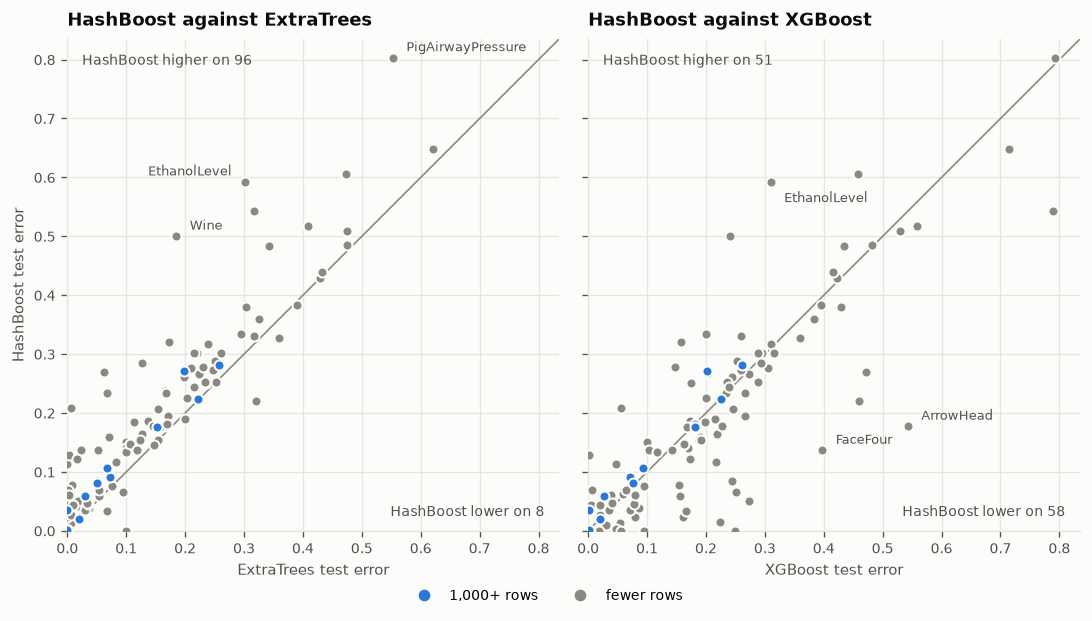

In [10]:
limit = float(error.to_numpy().max()) * 1.04
small = ~error.index.isin(large)

fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.9), sharey=True)
widest = {}

for ax, other in zip(axes, ["extratrees", "xgboost"]):
    x, y = error[other], error["hashboost"]

    ax.plot([0, limit], [0, limit], color=MUTED, lw=1, zorder=1)

    dot(ax, x[small], y[small], MUTED)
    dot(ax, x[~small], y[~small], BLUE)

    difference = y - x
    better, worse = (difference < 0).sum(), (difference > 0).sum()

    ax.text(
        0.97,
        0.03,
        f"HashBoost lower on {better}",
        transform=ax.transAxes,
        ha="right",
        fontsize=8.5,
        color=INK_2,
    )
    ax.text(
        0.03,
        0.97,
        f"HashBoost higher on {worse}",
        transform=ax.transAxes,
        va="top",
        fontsize=8.5,
        color=INK_2,
    )

    ax.set_xlim(0, limit)
    ax.set_ylim(0, limit)
    ax.set_aspect("equal")

    finish(
        ax,
        title=f"HashBoost against {NAMES[other]}",
        xlabel=f"{NAMES[other]} test error",
        ylabel="HashBoost test error" if other == "extratrees" else None,
    )

    widest[other] = difference.abs().sort_values(ascending=False).index[:3]

fig.legend(
    handles=[
        Line2D([], [], marker="o", ls="none", color=BLUE, label=f"{LARGE:,}+ rows"),
        Line2D([], [], marker="o", ls="none", color=MUTED, label="fewer rows"),
    ],
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(0.5, -0.03),
)
fig.tight_layout(rect=(0, 0.04, 1, 1))

# name the three widest gaps in each panel, and let the tables carry the rest
for ax, other in zip(axes, ["extratrees", "xgboost"]):
    x, y = error[other], error["hashboost"]
    place_labels(
        ax,
        [(x[name], y[name], name) for name in widest[other]],
        list(zip(x, y)),
    )

save(fig, "ucr_scatter")

HashBoost's record against XGBoost depends on the size of the training set,
while its record against ExtraTrees does not.

In [11]:
bands = pd.cut(
    meta.n_tr, [0, 50, 200, 999, np.inf], labels=["<=50", "51-200", "201-999", "1,000+"]
)


def record(other):
    """HashBoost's W/T/L against one model, per band of training-set size."""

    difference = error["hashboost"] - error[other]
    grouped = difference.groupby(bands, observed=True)

    return grouped.apply(
        lambda d: f"{(d < 0).sum()}/{(d == 0).sum()}/{(d > 0).sum()}"
    ).rename(f"W/T/L vs {NAMES[other]}")


pd.concat(
    [
        bands.value_counts().sort_index().rename("datasets"),
        record("extratrees"),
        record("xgboost"),
        error.groupby(bands, observed=True).mean().round(4).rename(columns=NAMES),
    ],
    axis=1,
)

,datasets,W/T/L vs ExtraTrees,W/T/L vs XGBoost,HashBoost,ExtraTrees,XGBoost
n_tr,,,,,,
<=50,27,3/0/24,19/1/7,0.1141,0.0646,0.1841
51-200,31,2/4/25,20/1/10,0.1981,0.1404,0.2198
201-999,43,2/4/37,16/1/26,0.2598,0.2176,0.2461
"1,000+",11,1/0/10,3/0/8,0.1225,0.0973,0.1054


## Training time

This is fit time only, with the QUANT transform shared and excluded.
HashBoost and XGBoost ran on the GPU. ExtraTrees ran on the CPU with 12
threads. HashBoost's 800 rounds are a fixed budget, so its time depends on
the batch size and not on how easy the dataset is. A set that fits in one
batch is re-accumulated every round.

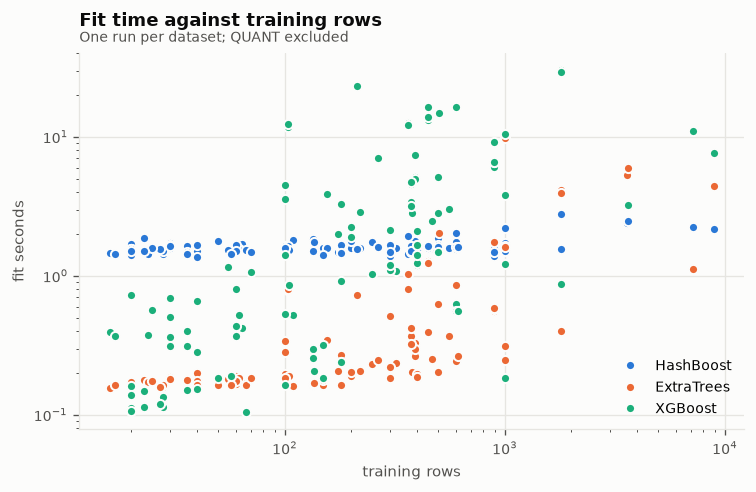

In [12]:
fig, ax = plt.subplots(figsize=(6.4, 4.2))

for model in MODELS:
    dot(ax, meta.n_tr, fit_s[model], COLOURS[model], size=5.5, label=NAMES[model])

ax.set_xscale("log")
ax.set_yscale("log")

finish(
    ax,
    title="Fit time against training rows",
    note="One run per dataset; QUANT excluded",
    xlabel="training rows",
    ylabel="fit seconds",
)
ax.legend(loc="lower right")
fig.tight_layout()
save(fig, "ucr_time")

In [13]:
pd.DataFrame(
    {
        "median fit s": fit_s.median(),
        "total fit s": fit_s.sum(),
        "total fit s, large": fit_s.loc[large].sum(),
    }
).rename(index=NAMES).round(2)

,median fit s,total fit s,"total fit s, large"
model,,,
HashBoost,1.58,182.98,23.61
ExtraTrees,0.20,70.17,37.30
XGBoost,1.18,413.06,101.44


## Is 800 rounds enough?

These are HashBoost's test error at intermediate rounds, read from the
recorded curves. This is a diagnostic of the fixed budget, and nothing is
chosen on it.

In [14]:
checkpoints = [100, 200, 400, 600, 800]

pd.DataFrame(
    {
        "mean test error": curves[checkpoints].mean(),
        "mean, large": curves.loc[large, checkpoints].mean(),
        "datasets lower than at 400": (
            curves[checkpoints].lt(curves[400], axis=0).sum()
        ),
        "datasets higher than at 400": (
            curves[checkpoints].gt(curves[400], axis=0).sum()
        ),
    }
).T.round(4)

,100,200,400,600,800
mean test error,0.2221,0.2104,0.2018,0.1975,0.1941
"mean, large",0.1543,0.1396,0.1296,0.1242,0.1225
datasets lower than at 400,14.0000,18.0000,0.0000,68.0000,73.0000
datasets higher than at 400,85.0000,70.0000,0.0000,18.0000,16.0000


In [15]:
# how often each model memorises its training set
(train_error == 0).sum().rename(index=NAMES).rename("datasets with zero train error")

model
HashBoost     111
ExtraTrees    111
XGBoost       110
Name: datasets with zero train error, dtype: int64

## What this says

These are one run per dataset, at commit `84ac59c`.

* **The pipeline reproduces published QUANT.** Our ExtraTrees has a mean
  error of 0.1475 against published QUANT's 0.1456 on the same splits, with
  correlation 0.996. The 12 datasets that disagree by more than 0.02 split
  six each way. The widest gap, 0.048 on Ham, is five of its 105 test series:
  the scatter of a different forest, not a shift.
* **Default HashBoost is significantly worse than QUANT's own classifier.**
  Its mean rank is 2.36 against 1.25 (Nemenyi CD 0.31), its mean error is
  0.194 against 0.148, and its error is higher on 96 of the 112 datasets.
* **It is level with default XGBoost.** Mean ranks are 2.36 and 2.39, the
  Holm-adjusted Wilcoxon p is 0.08, and the record is 58/3/51. The record
  depends on size: HashBoost wins 39 of the 58 sets with at most 200 training
  rows, where XGBoost's defaults struggle, and loses 8 of the 11 with 1,000 or
  more.
* **On the 11 large sets it is the fastest in total and the least
  accurate.** It fits each in 1.5 to 2.8 s, 24 s in all, against 37 s for
  ExtraTrees and 101 s for XGBoost. ExtraTrees is still quicker on five of
  them (Crop, PhalangesOutlinesCorrect, StarLightCurves, TwoPatterns, Wafer).
  HashBoost's mean error there is 0.123, against 0.097 and 0.105.
* **The 800-round budget is not a ceiling.** Mean test error still falls
  from 0.202 at 400 rounds to 0.194 at 800, and it is lower at 800 than at
  400 on 73 datasets. HashBoost reaches zero training error on 111 of the 112
  datasets and keeps improving on test after that, as boosting past a
  memorised training set often does. This is a diagnostic; nothing was chosen
  on it.

## Bits and rounds

This is a grid over HashBoost's two cheapest settings: 2, 4, 6 or 8 bits, and
800 or 3,200 rounds. The grid was run at commit `eb898d0`, one run per
cell, with the default (8 bits, 800 rounds) rerun in the same sweep as the
control. Everything else is as above.

UCR has no validation split, so this is a **sensitivity study on the test
sets**. It shows how test error moves with each setting. Picking the best
cell from it and quoting that cell's error would be choosing on test, and
that number would be optimistic.

In [16]:
GRID = "eb898d0"

BITS = [2, 4, 6, 8]
ROUNDS = [800, 3200]
CONFIGS = [f"hb_b{b}_r{r}" for r in ROUNDS for b in BITS]
CONTROL = "hb_b8_r800"


def load_grid(paths):
    """-> one row per (dataset, grid cell)."""

    rows = []

    for path in paths:
        blob = json.loads(path.read_text())

        for label, entry in blob["models"].items():
            fit = next(t for t in entry["timings"] if t["phase"] == "fit")

            rows.append(
                {
                    "dataset": blob["dataset"],
                    "config": label,
                    "bits": entry["params"]["num_bits"],
                    "rounds": entry["params"]["rounds"],
                    "error": entry["final"]["te"],
                    "train_error": entry["final"]["tr"],
                    "fit_s": fit["wall_s"],
                }
            )

    return pd.DataFrame(rows)


grid = load_grid(sorted(RESULTS.glob(f"*-{GRID}.json")))
grid = grid[grid.config.isin(CONFIGS)]

grid_error = grid.pivot(index="dataset", columns="config", values="error")[CONFIGS]
grid_fit = grid.pivot(index="dataset", columns="config", values="fit_s")[CONFIGS]

assert len(grid_error) == 112 and not grid_error.isna().any().any()

### How much a rerun moves

The control repeats the default configuration from the benchmark above. The
features are identical, so the only difference between the two runs is
HashBoost's run-to-run noise. That noise is the floor any cell of the grid
has to clear.

In [17]:
rerun = grid_error[CONTROL] - error["hashboost"]

pd.Series(
    {
        "mean error, first run": error["hashboost"].mean(),
        "mean error, control rerun": grid_error[CONTROL].mean(),
        "datasets that moved": (rerun != 0).sum(),
        "mean absolute change": rerun.abs().mean(),
        "largest change": rerun.abs().max(),
        "Wilcoxon p, first run against rerun": stats.wilcoxon(
            grid_error[CONTROL], error["hashboost"]
        ).pvalue,
    }
).round(4)

mean error, first run                   0.1941
mean error, control rerun               0.1956
datasets that moved                    41.0000
mean absolute change                    0.0036
largest change                          0.0667
Wilcoxon p, first run against rerun     0.2064
dtype: float64

### The grid

These are mean test error over the 112 datasets for each cell, and each
cell's record against the control. W/T/L counts the datasets where the cell's
error is lower, equal and higher. p is a two-sided Wilcoxon signed-rank test
against the control, Holm-adjusted over the seven comparisons. Mean rank is
among the eight cells.

In [18]:
cells = [c for c in CONFIGS if c != CONTROL]
p_grid = dict(
    zip(
        cells,
        holm(
            [stats.wilcoxon(grid_error[c], grid_error[CONTROL]).pvalue for c in cells]
        ),
    )
)
grid_ranks = grid_error.rank(axis=1, method="average").mean()

rows = {}
for config in CONFIGS:
    difference = grid_error[config] - grid_error[CONTROL]
    bits, rounds = config.split("_")[1:]

    rows[config] = {
        "bits": int(bits[1:]),
        "rounds": int(rounds[1:]),
        "mean error": f"{grid_error[config].mean():.4f}",
        "mean rank": f"{grid_ranks[config]:.2f}",
        "W/T/L vs control": (
            "--"
            if config == CONTROL
            else f"{(difference < 0).sum()}/{(difference == 0).sum()}"
            f"/{(difference > 0).sum()}"
        ),
        "p (Holm)": f"{p_grid[config]:.2g}" if config in p_grid else "--",
        "total fit s": f"{grid_fit[config].sum():.0f}",
    }

pd.DataFrame(rows).T

,bits,rounds,mean error,mean rank,W/T/L vs control,p (Holm),total fit s
hb_b2_r800,2,800,0.1750,4.17,75/14/23,5.2e-07,188
hb_b4_r800,4,800,0.1767,4.16,87/11/14,1.8e-11,179
hb_b6_r800,6,800,0.1844,5.31,73/17/22,3.6e-08,185
hb_b8_r800,8,800,0.1956,6.51,--,--,182
hb_b2_r3200,2,3200,0.1647,2.63,89/9/14,2.7e-12,1413
hb_b4_r3200,4,3200,0.1712,3.04,92/9/11,1.3e-13,1329
hb_b6_r3200,6,3200,0.1808,4.47,84/12/16,8.8e-12,1339
hb_b8_r3200,8,3200,0.1885,5.69,70/23/19,1.8e-07,1377


### By training-set size

The case for fewer bits is that a small training set cannot fill 256
buckets, so the best bit width should fall as the training set shrinks. Each
panel below is one size band. The lines are the two round budgets across the
four bit widths.

In [19]:
grid_bands = pd.cut(
    meta.n_tr, [0, 50, 200, 999, np.inf], labels=["<=50", "51-200", "201-999", "1,000+"]
)
by_band = grid.assign(band=grid.dataset.map(grid_bands)).pivot_table(
    index=["band", "rounds"],
    columns="bits",
    values="error",
    aggfunc="mean",
    observed=True,
)

by_band.round(4)

bits                 2       4       6       8
band    rounds                                
<=50    800     0.0771  0.0909  0.1016  0.1179
        3200    0.0759  0.0852  0.1020  0.1057
51-200  800     0.1717  0.1756  0.1849  0.1998
        3200    0.1636  0.1729  0.1810  0.1913
201-999 800     0.2512  0.2479  0.2526  0.2601
        3200    0.2353  0.2409  0.2477  0.2564
1,000+  800     0.1268  0.1125  0.1195  0.1229
        3200    0.1101  0.1050  0.1126  0.1181

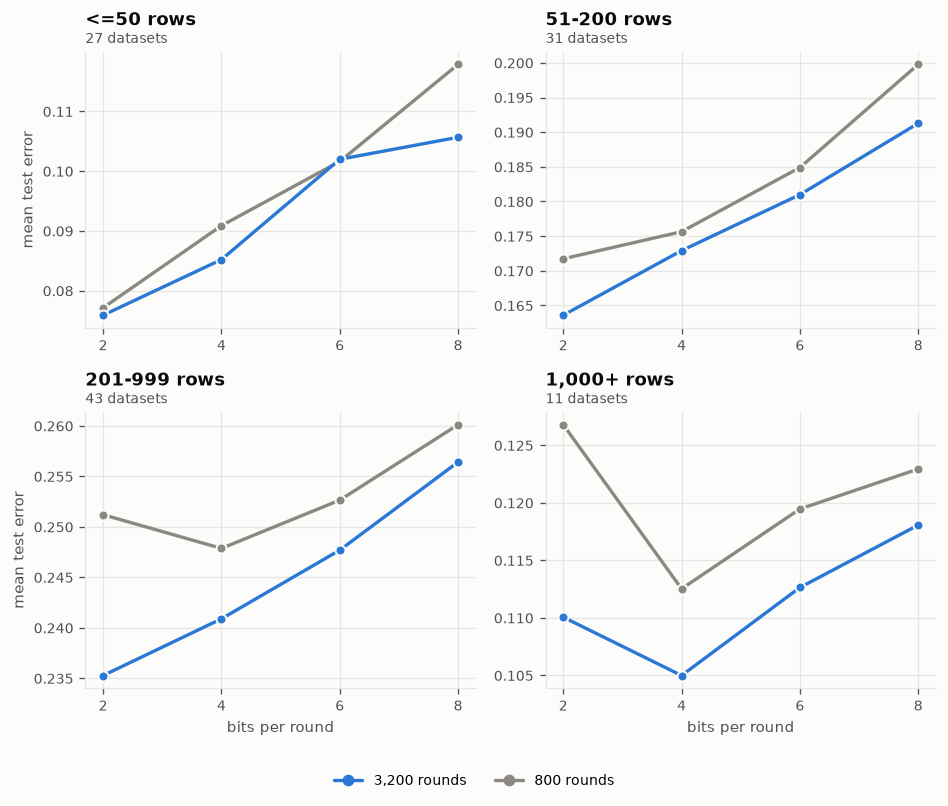

In [20]:
ROUND_COLOURS = {800: MUTED, 3200: BLUE}

fig, axes = plt.subplots(2, 2, figsize=(8.0, 6.6))

for i, (ax, band) in enumerate(zip(axes.flat, grid_bands.cat.categories)):
    count = (grid_bands == band).sum()

    for rounds in ROUNDS:
        values = by_band.loc[(band, rounds)]
        ax.plot(values.index, values.to_numpy(), color=ROUND_COLOURS[rounds], zorder=3)
        dot(ax, values.index, values.to_numpy(), ROUND_COLOURS[rounds], size=6)

    ax.set_xticks(BITS)
    finish(
        ax,
        title=f"{band} rows",
        note=f"{count} datasets",
        xlabel="bits per round" if i >= 2 else None,
        ylabel="mean test error" if i % 2 == 0 else None,
    )

fig.legend(
    handles=[
        Line2D([], [], color=BLUE, marker="o", label="3,200 rounds"),
        Line2D([], [], color=MUTED, marker="o", label="800 rounds"),
    ],
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(0.5, -0.02),
)
fig.tight_layout(rect=(0, 0.04, 1, 1))
save(fig, "ucr_bits_rounds")

### Choosing a cell without choosing on the same test sets

To put a number on what the grid buys without the optimism of picking on the
datasets it is scored on, the cell is chosen on one random half of the
datasets and scored on the other half, both ways round. Every dataset is then
scored by a cell chosen without looking at it. This is two-fold
cross-validation over datasets. It still chooses among only eight cells, and
it still reads test sets to choose, but never the one being scored.

In [21]:
half = pd.Series(
    np.random.default_rng(42).permutation(len(grid_error)) % 2, index=grid_error.index
)
chosen = {h: grid_error[half == h].mean().idxmin() for h in (0, 1)}

crossed = pd.Series(
    {name: grid_error.loc[name, chosen[1 - half[name]]] for name in grid_error.index}
).rename("grid, chosen on the other half")

print(f"chosen on half 0: {chosen[0]}; chosen on half 1: {chosen[1]}")

chosen on half 0: hb_b2_r3200; chosen on half 1: hb_b2_r3200


### Against the baselines

This sets the grid beside ExtraTrees and XGBoost from the benchmark above,
which ran on the same features. There are two grid rows. One is the
cross-validated choice from the previous cell. The other is the single best
cell over all 112 datasets. That one is chosen on the test sets it is scored
on, so read it as an upper bound on what these two settings can buy, not as
a result.

In [22]:
best = grid_error.mean().idxmin()

beside = pd.concat(
    [
        grid_error[CONTROL].rename(f"{CONTROL} (control)"),
        crossed,
        grid_error[best].rename(f"{best} (best on test)"),
        error["extratrees"].rename("ExtraTrees"),
        error["xgboost"].rename("XGBoost"),
    ],
    axis=1,
)

# HashBoost's cross-validated choice against each column. A column identical
# to it -- the best cell, when both halves chose that same cell -- has no test.
reference = crossed.name
others = [c for c in beside.columns if c != reference and (beside[c] != crossed).any()]
p_beside = dict(
    zip(
        others,
        holm([stats.wilcoxon(beside[reference], beside[c]).pvalue for c in others]),
    )
)

pd.DataFrame(
    {
        "mean error": beside.mean().map("{:.4f}".format),
        "mean rank (these five)": beside.rank(axis=1, method="average")
        .mean()
        .map("{:.2f}".format),
        "cross-validated W/T/L": [
            "--"
            if c == reference
            else f"{(beside[reference] < beside[c]).sum()}"
            f"/{(beside[reference] == beside[c]).sum()}"
            f"/{(beside[reference] > beside[c]).sum()}"
            for c in beside.columns
        ],
        "p (Holm)": [
            f"{p_beside[c]:.2g}" if c in p_beside else "--" for c in beside.columns
        ],
    }
)

,mean error,mean rank (these five),cross-validated W/T/L,p (Holm)
hb_b8_r800 (control),0.1956,4.02,89/9/14,1.4e-12
"grid, chosen on the other half",0.1647,2.58,--,--
hb_b2_r3200 (best on test),0.1647,2.58,0/112/0,--
ExtraTrees,0.1475,1.95,28/21/63,1.2e-05
XGBoost,0.2101,3.86,82/1/29,4.5e-08


### What the grid says

These are one run per cell, at commit `eb898d0`.

* **A rerun moves little on average.** The control reads 0.1956 against the
  first run's 0.1941. It changed 41 of the 112 datasets, with a mean absolute
  change of 0.0036 over all 112 and no systematic direction (Wilcoxon
  p = 0.21).
* **Fewer bits help at both budgets, and every cell beats the default.** At
  800 rounds the mean error goes 0.1956, 0.1844, 0.1767, 0.1750 from 8 bits
  down to 2. At 3,200 rounds it goes 0.1885, 0.1808, 0.1712, 0.1647. All seven
  cells beat the control (Holm p at most 5.2e-7).
* **More rounds help at every width, and most at 2 bits** (0.1750 to 0.1647),
  where each round is the weakest learner. Within the 2-bit runs the prefix
  error is still falling but flattening: 0.1689 at 1,600 rounds, 0.1658 at
  2,400 and 0.1647 at 3,200.
* **The best width grows with the training set, as the bucket argument
  predicts.** At 3,200 rounds, 2 bits is best in every band below 1,000 rows,
  and 4 bits is best at 1,000 or more (0.1050 against 0.1101). The gain from 8
  to 2 bits at 800 rounds is larger where there are fewer training rows per
  class (r = -0.34 against log n/k).
* **Chosen without reading the scored test sets, the grid is significantly
  ahead of XGBoost and still behind ExtraTrees.** Both halves chose 2 bits and
  3,200 rounds. Against XGBoost that choice is lower on 82 datasets and
  higher on 29 (Holm p = 4.5e-8). Against ExtraTrees it is lower on 28 and
  higher on 63 (p = 1.2e-5). The gap in mean error shrinks from 0.048 to
  0.017.
* **Bits are free and rounds are not.** On sets this small the cost is
  per-round overhead: the four 800-round cells take 179 to 188 s over all 112
  datasets whatever the width, and the 3,200-round cells take 1,329 to
  1,413 s. So 2 bits at 800 rounds is 0.021 better than the default at the
  same cost, and 3,200 rounds buys another 0.010 at 7.5 times the time.
  ExtraTrees takes 70 s on the CPU.